<table align="left">
  <td>
    <a href="https://colab.research.google.com/drive/1QaVU03VlON5QNvGSxNHiR5t2f-gWwAbh?usp=sharing" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

**1. Import Libraries and Load Data**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error


**Step 2: Data Preprocessing**

In [ ]:
# Load the dataset
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv'
data = pd.read_csv(url, parse_dates=['Date'], index_col='Date')
data.head(3)

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8


In [ ]:
# Scale the data
scaler      = MinMaxScaler(feature_range=(0, 1))
data['Temp'] = scaler.fit_transform(data['Temp'].values.reshape(-1, 1)) # Converts into a 2D

In [ ]:
# Split data into training and testing sets
train_size = int(len(data) * 0.8)
train, test = data[:train_size], data[train_size:]

In [ ]:
# Prepare sequences

def create_sequences(data, time_steps=30):
    X, y = [], [] # # Initialize empty lists for input sequences (X) and targets (y)
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
        y.append(data[i+time_steps])
    return np.array(X), np.array(y)

time_steps = 30
X_train, y_train = create_sequences(train['Temp'].values, time_steps)
X_test, y_test   = create_sequences(test['Temp'].values, time_steps)


In [ ]:
# Reshape to 3D for RNN/LSTM input
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [ ]:
def train_model(model, X_train, y_train, epochs=50):
    history = model.fit(X_train, y_train, epochs=epochs)
    return model, history



def evaluate_model(model, X_test, y_test, title='Model Evaluation'):

    # Make predictions on test set
    predictions   = model.predict(X_test)
    predictions   = scaler.inverse_transform(predictions)
    y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

    # Calculate MSE
    mse = mean_squared_error(y_test_actual, predictions)
    print(f'{title} - Mean Squared Error on Test Set: {mse}')

    # Plotting
    plt.figure(figsize=(14, 7))
    plt.plot(data.index[-len(y_test):], y_test_actual, label='Actual Temperatures', color='blue')
    plt.plot(data.index[-len(y_test):], predictions, label=f'{title} Predictions', color='orange')
    plt.title(f'{title} - Actual vs Predicted')
    plt.xlabel('Date')
    plt.ylabel('Temperature (°C)')
    plt.legend()
    plt.show()
    return predictions, mse



def forecast_future(model, last_sequence, n_steps=30):

    predictions = []
    current_sequence = last_sequence

    # Update sequence with latest prediction
    for _ in range(n_steps):
        next_value       = model.predict(current_sequence.reshape(1, time_steps, 1))
        predictions.append(next_value[0, 0])
        current_sequence = np.append(current_sequence[1:], next_value)

    # Inverse transform predictions
    future_predictions = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))
    return future_predictions

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

rnn_model = Sequential() #Initialize a Sequential model, which allows you to add layers one by one.
rnn_model.add(SimpleRNN(50, input_shape=(time_steps, 1)))  # 50 units
rnn_model.add(Dense(1))  # Output layer

rnn_model.compile(optimizer='adam', loss='mse')

# Fit the model
# rnn_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0491 - val_loss: 0.0093
Epoch 2/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0112 - val_loss: 0.0080
Epoch 3/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0098 - val_loss: 0.0075
Epoch 4/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0096 - val_loss: 0.0088
Epoch 5/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0092 - val_loss: 0.0087
Epoch 6/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0089 - val_loss: 0.0078
Epoch 7/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0094 - val_loss: 0.0075
Epoch 8/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0093 - val_loss: 0.0078
Epoch 9/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0093 - val_loss: 0.0076
Epoch 10/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0087 - val_loss: 0.0072
Epoch 11/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0090 - val_loss: 0.0072
Epoch 12/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0092 - val_loss: 0.007

We are adding a SimpleRNN layer with 50 “memory cells” (hidden units).

input_shape=(time_steps, 1) means:

The model looks at the past 30 time points (time_steps) to make a prediction.

There is only 1 feature at each time point (the temperature).

The RNN remembers patterns in the sequence of temperatures.

After looking at the 30 past points, it produces 50 numbers (one for each hidden unit) that summarize what it learned from that sequence.

In short: the RNN looks at the last 30 temperatures, remembers patterns, and summarizes them into 50 values that the next layer will use to predict the next temperature.

If you like, I can make a small diagram showing this “memory” visually, which makes it really easy to understand. Do you want me to do that?

Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0088
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0087
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0089
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0090
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0091
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0088
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0092
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0090
Epoch 9/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0087
Epoch 10/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0092
Epoch 11/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0092
Epoch 12/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0088
Epoch 13/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0089
Epoch 14/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0087
Epoch 15/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0089
Epoch 16/50
91/

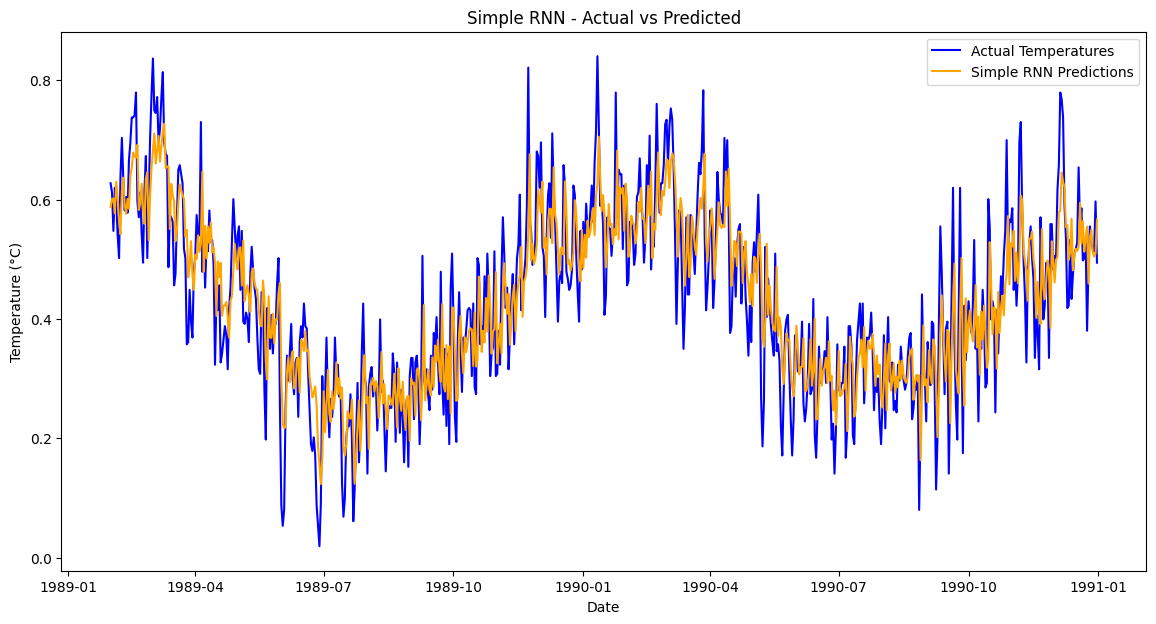

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━

In [ ]:
simple_rnn, _                          = train_model(rnn_model, X_train, y_train)
simple_rnn_predictions, simple_rnn_mse = evaluate_model(rnn_model, X_test, y_test, title='Simple RNN')
future_simple_rnn                      = forecast_future(simple_rnn, X_test[-1])

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0523
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0109
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0115
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0104
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0109
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0106
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0100
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0105
Epoch 9/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0102
Epoch 10/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0094
Epoch 11/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0101
Epoch 12/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0089
Epoch 13/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0094
Epoch 14/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0091
Epoch 15/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0088
Epoch 16/50
91/

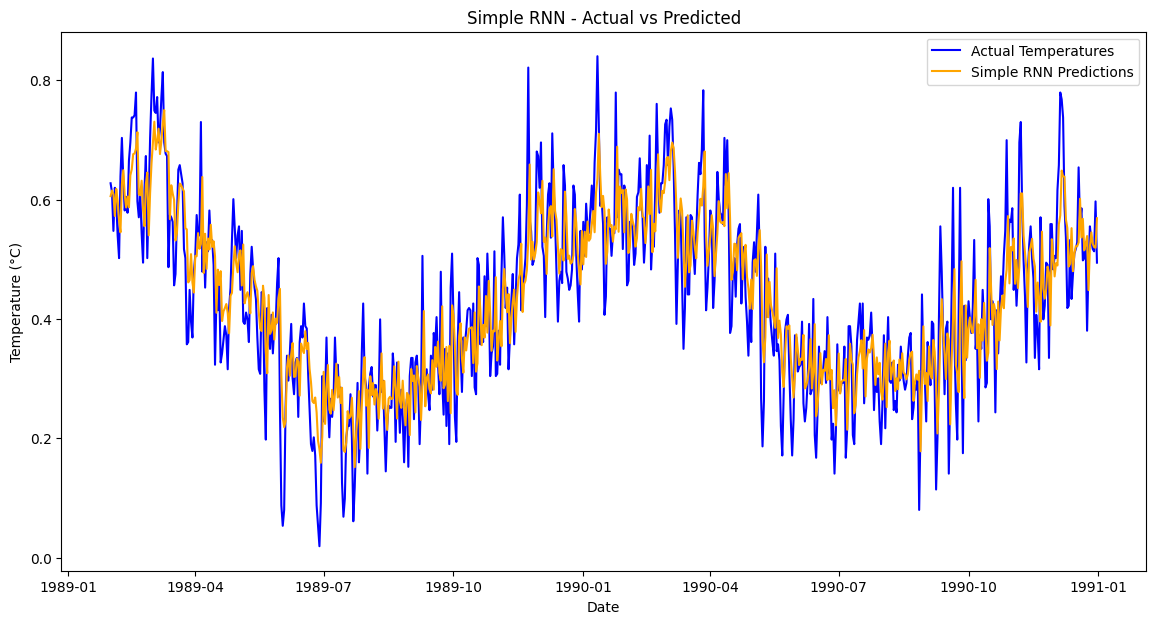

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━

In [ ]:
from tensorflow.keras.layers import LSTM

lstm_model = Sequential()
lstm_model.add(LSTM(50, input_shape=(time_steps, 1)))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer='adam', loss='mse')

# lstm_model.fit(X_train_reshaped, y_train, epochs=20, batch_size=32, validation_data=(X_test_reshaped, y_test))

lstm_model, _                          = train_model(lstm_model, X_train, y_train)
lstm_model_predictions, lstm_model_rnn_mse = evaluate_model(lstm_model, X_test, y_test, title='LSTM RNN')
future_lstm_model                      = forecast_future(lstm_model, X_test[-1])


In [ ]:
from tensorflow.keras.layers import GRU

gru_model = Sequential()
gru_model.add(GRU(50, input_shape=(time_steps, 1)))
gru_model.add(Dense(1))

gru_model.compile(optimizer='adam', loss='mse')

gru_model.fit(X_train_reshaped, y_train, epochs=20, batch_size=32, validation_data=(X_test_reshaped, y_test))

lstm_model, _                          = train_model(lstm_model, X_train, y_train)
lstm_model_predictions, lstm_model_rnn_mse = evaluate_model(lstm_model, X_test, y_test, title='LSTM RNN')
future_lstm_model                      = forecast_future(lstm_model, X_test[-1])


**Step 3 Reusable Functions for Model Creation, Training, and Prediction**

In [ ]:
def build_model(model_type='SimpleRNN', time_steps=30, units=50):

    model = Sequential()
    if model_type == 'SimpleRNN':
        model.add(SimpleRNN(units, activation='relu', input_shape=(time_steps, 1)))
    elif model_type == 'DeepRNN':
        model.add(SimpleRNN(units, activation='relu', return_sequences=True, input_shape=(time_steps, 1)))
        model.add(SimpleRNN(units, activation='relu'))
    elif model_type == 'LSTM':
        model.add(LSTM(units, activation='relu', return_sequences=True, input_shape=(time_steps, 1)))
        model.add(LSTM(units, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model


**Training, Evaluating, and Forecasting with Each Model**

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0520
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0107
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0102
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0092
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0091
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0086
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0086
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0086
Epoch 9/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0089
Epoch 10/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0094
Epoch 11/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0088
Epoch 12/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0085
Epoch 13/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0085
Epoch 14/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0089
Epoch 15/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0086
Epoch 16/50
91/91 ━━━━━━━━━

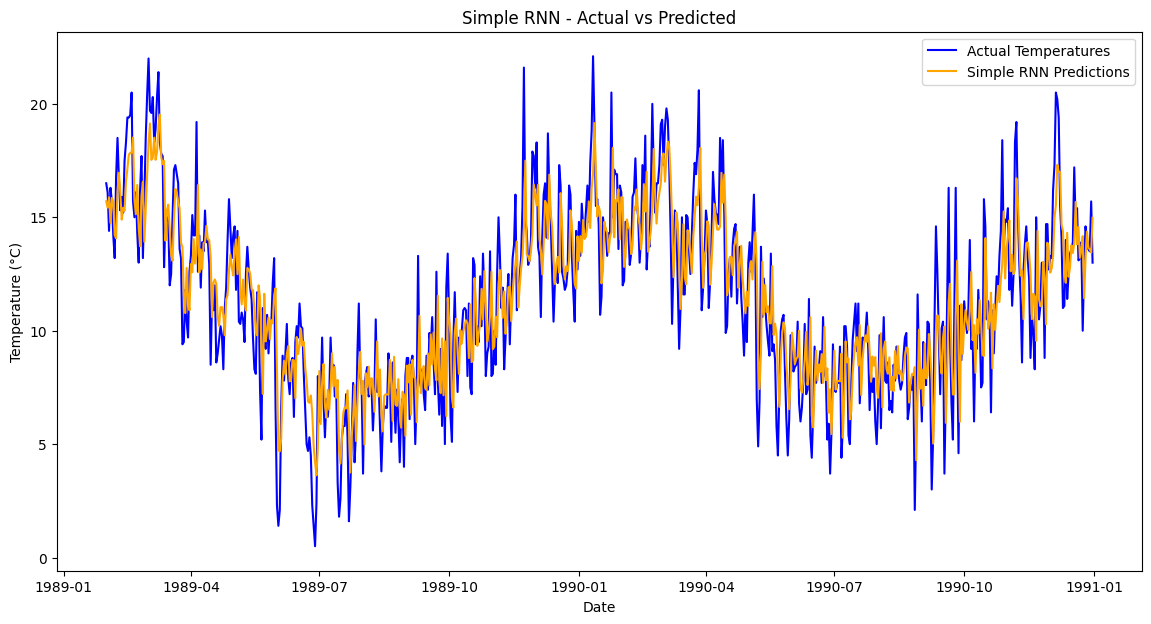

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━

In [ ]:
# Build, train, evaluate, and forecast with Simple RNN

simple_rnn = build_model(model_type='SimpleRNN')
simple_rnn, _ = train_model(simple_rnn, X_train, y_train)
simple_rnn_predictions, simple_rnn_mse = evaluate_model(simple_rnn, X_test, y_test, title='Simple RNN')
future_simple_rnn = forecast_future(simple_rnn, X_test[-1])

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0596
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0093
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0092
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0087
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0089
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0090
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0088
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0089
Epoch 9/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0092
Epoch 10/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0090
Epoch 11/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0090
Epoch 12/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0084
Epoch 13/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0089
Epoch 14/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0087
Epoch 15/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0085
Epoch 16/50
91/

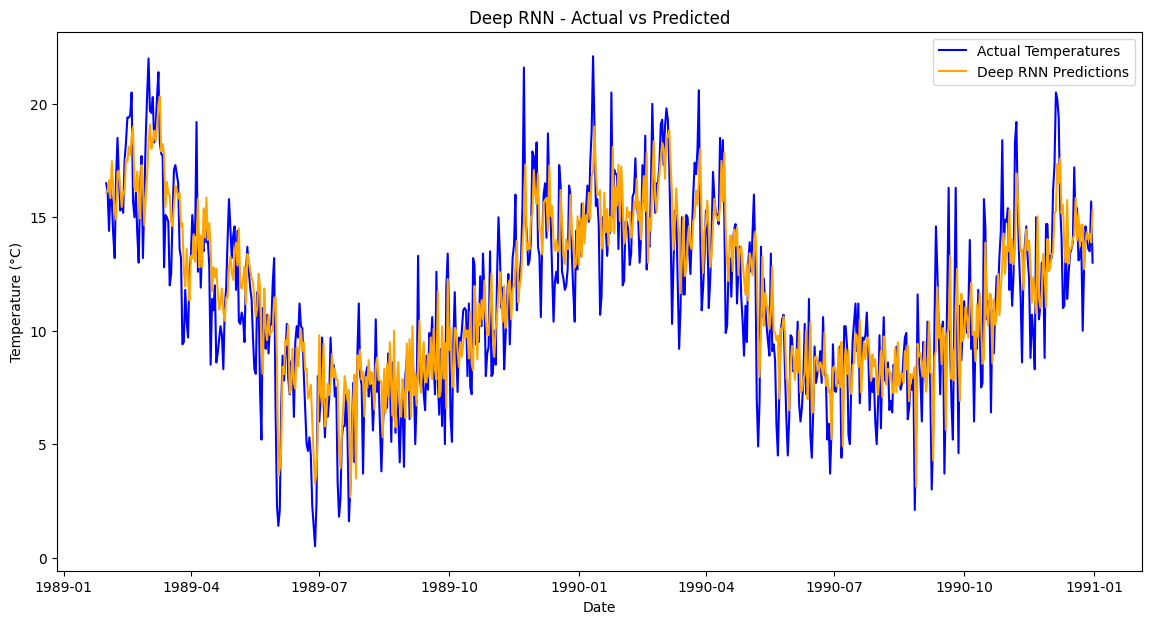

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━

In [ ]:
# Build, train, evaluate, and forecast with Deep RNN
deep_rnn = build_model(model_type='DeepRNN')
deep_rnn, _ = train_model(deep_rnn, X_train, y_train)
deep_rnn_predictions, deep_rnn_mse = evaluate_model(deep_rnn, X_test, y_test, title='Deep RNN')
future_deep_rnn = forecast_future(deep_rnn, X_test[-1])


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0837
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0120
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.0124
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0122
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0120
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0116
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0113
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0119
Epoch 9/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0106
Epoch 10/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0115
Epoch 11/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0107
Epoch 12/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0109
Epoch 13/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 0.0105
Epoch 14/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0106
Epoch 15/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0096
Epoch 16/50
91/

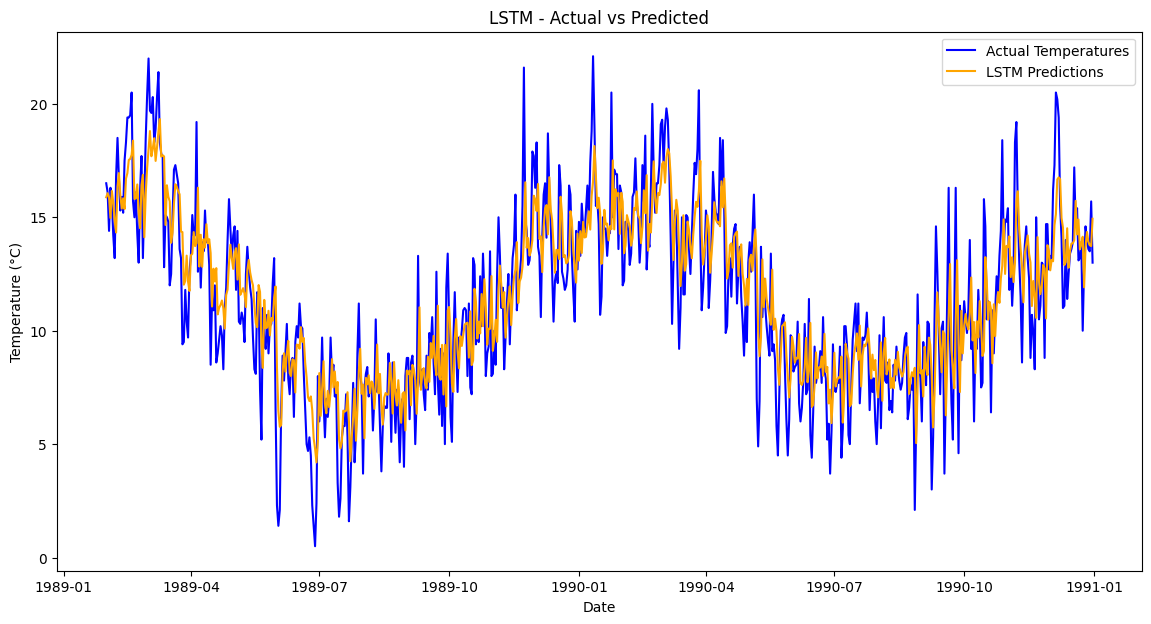

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━

In [ ]:
# Build, train, evaluate, and forecast with LSTM
lstm_model = build_model(model_type='LSTM')
lstm_model, _ = train_model(lstm_model, X_train, y_train)
lstm_predictions, lstm_mse = evaluate_model(lstm_model, X_test, y_test, title='LSTM')
future_lstm = forecast_future(lstm_model, X_test[-1])


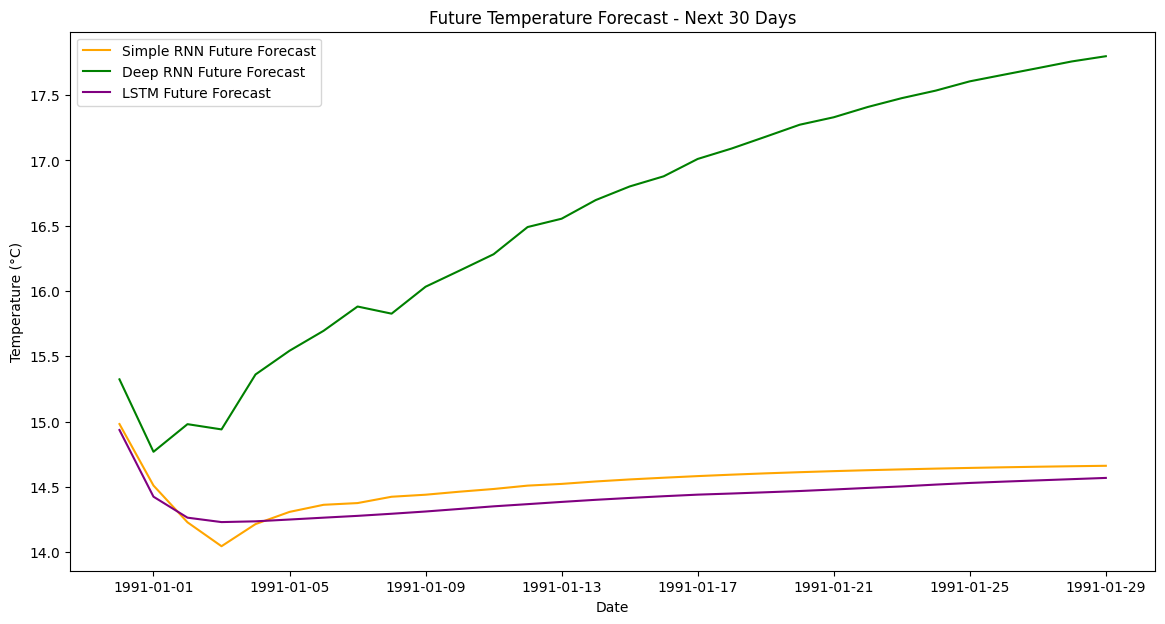

In [ ]:
# Plot future predictions
plt.figure(figsize=(14, 7))
future_dates = pd.date_range(data.index[-1], periods=30, freq='D')

plt.plot(future_dates, future_simple_rnn, label='Simple RNN Future Forecast', color='orange')
plt.plot(future_dates, future_deep_rnn, label='Deep RNN Future Forecast', color='green')
plt.plot(future_dates, future_lstm, label='LSTM Future Forecast', color='purple')

plt.title('Future Temperature Forecast - Next 30 Days')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()
